# Convolutional Neural Network for Indian Sign Language

## Part 1: Data Loading

In [1]:
# from google.colab import files
# !pip install kaggle

In [2]:
import os
os.environ['KAGGLE_API_TOKEN']='KGAT_6e25a135cbc02cae857e4e183f4c42de'

In [3]:
!kaggle datasets download -d eraakash/indian-sign-language-hand-landmarks-dataset
!unzip indian-sign-language-hand-landmarks-dataset -d isl_landmark

DIR="/content/isl_landmark"

Dataset URL: https://www.kaggle.com/datasets/eraakash/indian-sign-language-hand-landmarks-dataset
License(s): CC-BY-SA-4.0
100% 47.1M/47.1M [00:03<00:00, 15.8MB/s]

Archive:  indian-sign-language-hand-landmarks-dataset.zip
  inflating: isl_landmark/Indian Sign Language Gesture Landmarks.csv  


In [4]:
import pandas as pd

f=pd.read_csv("isl_landmark/Indian Sign Language Gesture Landmarks.csv")

class_names=[chr(i+65) for i in range(26)] # chars are from A to Z

labels=f["target"].values
vecs=f.drop(columns=["target"]).values

f.shape

(50859, 128)

In [5]:
import torch

torch.from_numpy(labels).shape,torch.from_numpy(vecs).shape

(torch.Size([50859]), torch.Size([50859, 127]))

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(vecs,labels,test_size=0.2,random_state=42,stratify=labels) # prevents uneven distribution of labels like 0% n test data and 100 % in train or vice versa

In [8]:
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
Y_train=torch.tensor(Y_train,dtype=torch.long)
Y_test=torch.tensor(Y_test,dtype=torch.long)

X_test.shape,X_train.shape,Y_test.shape,Y_train.shape

(torch.Size([10172, 127]),
 torch.Size([40687, 127]),
 torch.Size([10172]),
 torch.Size([40687]))

In [9]:
from torch.utils.data import DataLoader,TensorDataset

test_data=DataLoader(TensorDataset(X_train,Y_train),batch_size=64,shuffle=True)
train_data=DataLoader(TensorDataset(X_test,Y_test),batch_size=64,shuffle=False)

len(test_data), len(train_data)

(636, 159)

## Part 2: Model Definition

In [10]:
import torch.nn as nn

class ISL_Landmark(nn.Module):
  def __init__(self,num_labels):
    super().__init__()
    self.convolution=nn.Sequential(

        # Block 1:
        nn.Linear(127,256), # (50859, 127) -> (50859, 256)
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.2),

         # Block 2:
        nn.Linear(256,128), # (50859, 256) -> (50859, 128)
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(128,64), # (50859, 128) -> (50859, 64)
        nn.BatchNorm1d(64),
        nn.ReLU(),

        nn.Linear(64,len(class_names))

    )

    # self.fully_connected=nn.Sequential(
    #     nn.Flatten(), # (128,16,16) -> (32768)
    #     nn.Linear(128*16*16,512), # (512)
    #     nn.ReLU(),
    #     nn.Dropout(0.25), # prevents overfitting
    #     nn.Linear(512,128), # (128)
    #     nn.ReLU(),
    #     nn.Linear(128,num_labels) # (nm_labels) which is 40 in this case
    # )

  def forward(self,x):
    x=self.convolution(x)
    # x=self.fully_connected(x)
    return x

In [11]:
model_0=ISL_Landmark(len(class_names)).to(device)
model_0

ISL_Landmark(
  (convolution): Sequential(
    (0): Linear(in_features=127, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=26, bias=True)
  )
)

## Part 3: Training Loop

In [12]:
cost_func=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.001,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

In [13]:
def accuracy(y_actual,y_pred):
  correct=torch.eq(y_actual,y_pred).sum()
  acc=(correct.item()/len(y_pred))*100
  return acc

In [14]:
torch.manual_seed(42)

epochs=80

for epoch in range(epochs):
  train_loss=0

  # now, go through all batches per epoch
  for batch,(x,y) in enumerate(train_data):
    # batchnum,tensor of all 64 images, tensor of all 64 labels
    model_0.train()

    x=x.to(device)
    y=y.to(device)

    y_pred=model_0(x)

    loss=cost_func(y_pred,y)

    train_loss+=loss.item() # .item() dont add tensors again!!!

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (batch%100)==0:
      print(f"{(batch*len(x))/len(train_data.dataset)} Completed")

  train_loss/=len(train_data)

  test_loss=0
  test_acc=0

  with torch.inference_mode():
    model_0.eval()

    for X,Y in test_data:

      X=X.to(device)
      Y=Y.to(device)

      test_pred=model_0(X)
      test_loss+=cost_func(test_pred,Y).item()
      test_acc+=accuracy(Y,test_pred.argmax(dim=1))
      # test pred will be [64,40], so u need the max i the 40 waala dim to getthe predicted label

    test_loss/=len(test_data)
    test_acc/=len(test_data)

  scheduler.step(test_loss)

  if(epoch%2==0):
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


0.0 Completed
0.6291781360597719 Completed
Epoch: 0 | Train Loss: 1.8160 | Test Loss: 0.9199 | Test Acc: 78.5230
0.0 Completed
0.6291781360597719 Completed
0.0 Completed
0.6291781360597719 Completed
Epoch: 2 | Train Loss: 0.4433 | Test Loss: 0.2925 | Test Acc: 91.0351
0.0 Completed
0.6291781360597719 Completed
0.0 Completed
0.6291781360597719 Completed
Epoch: 4 | Train Loss: 0.3217 | Test Loss: 0.1734 | Test Acc: 95.3056
0.0 Completed
0.6291781360597719 Completed
0.0 Completed
0.6291781360597719 Completed
Epoch: 6 | Train Loss: 0.2476 | Test Loss: 0.1336 | Test Acc: 95.6620
0.0 Completed
0.6291781360597719 Completed
0.0 Completed
0.6291781360597719 Completed
Epoch: 8 | Train Loss: 0.2185 | Test Loss: 0.1461 | Test Acc: 94.3834
0.0 Completed
0.6291781360597719 Completed
0.0 Completed
0.6291781360597719 Completed
Epoch: 10 | Train Loss: 0.1539 | Test Loss: 0.0785 | Test Acc: 97.4229
0.0 Completed
0.6291781360597719 Completed
0.0 Completed
0.6291781360597719 Completed
Epoch: 12 | Train Lo

## Part 4: Saving the Model

In [15]:
torch.save(model_0.state_dict(),"isl_landmark_model.pth")
from google.colab import files
files.download("isl_landmark_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import json

data={
    'class_names': class_names,
}
with open("class_names.json", "w", encoding="utf-8") as f:
    json.dump(data, f)
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
model_1=ISL_Landmark(len(class_names)).to(device)
model_1.load_state_dict(torch.load("isl_landmark_model.pth"))
model_1.eval()

ISL_Landmark(
  (convolution): Sequential(
    (0): Linear(in_features=127, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=26, bias=True)
  )
)

## Part 5: Testing the Model

In [18]:
model_0.eval()

X_eval=X_test[0].unsqueeze(0).to(device) # add batch dim with unsqueeze
Y_eval=Y_test[0]

with torch.inference_mode():

    pred=model_0(X_eval).softmax(dim=1)[0]
    pred_idx=pred.argmax().item()


X_eval.shape,pred.shape,class_names[pred_idx],class_names[Y_eval]

(torch.Size([1, 127]), torch.Size([26]), 'U', 'U')

In [19]:
model_0.eval()
with torch.inference_mode():
    X,Y = next(iter(test_data))
    X,Y = X.to(device),Y.to(device)
    pred=model_0(X).argmax(dim=1)

pred.shape

torch.Size([64])

In [20]:
# for x,y in enumerate(train_dataloader):
#   print(x,y)

## Part 6: Confusion Matrix

In [21]:
!pip install torchmetrics
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 3.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/plot_confusion_matrix.py:102: RuntimeWarning: invalid value encountered in divide
  normed_conf_mat = conf_mat.astype("float") / total_samples


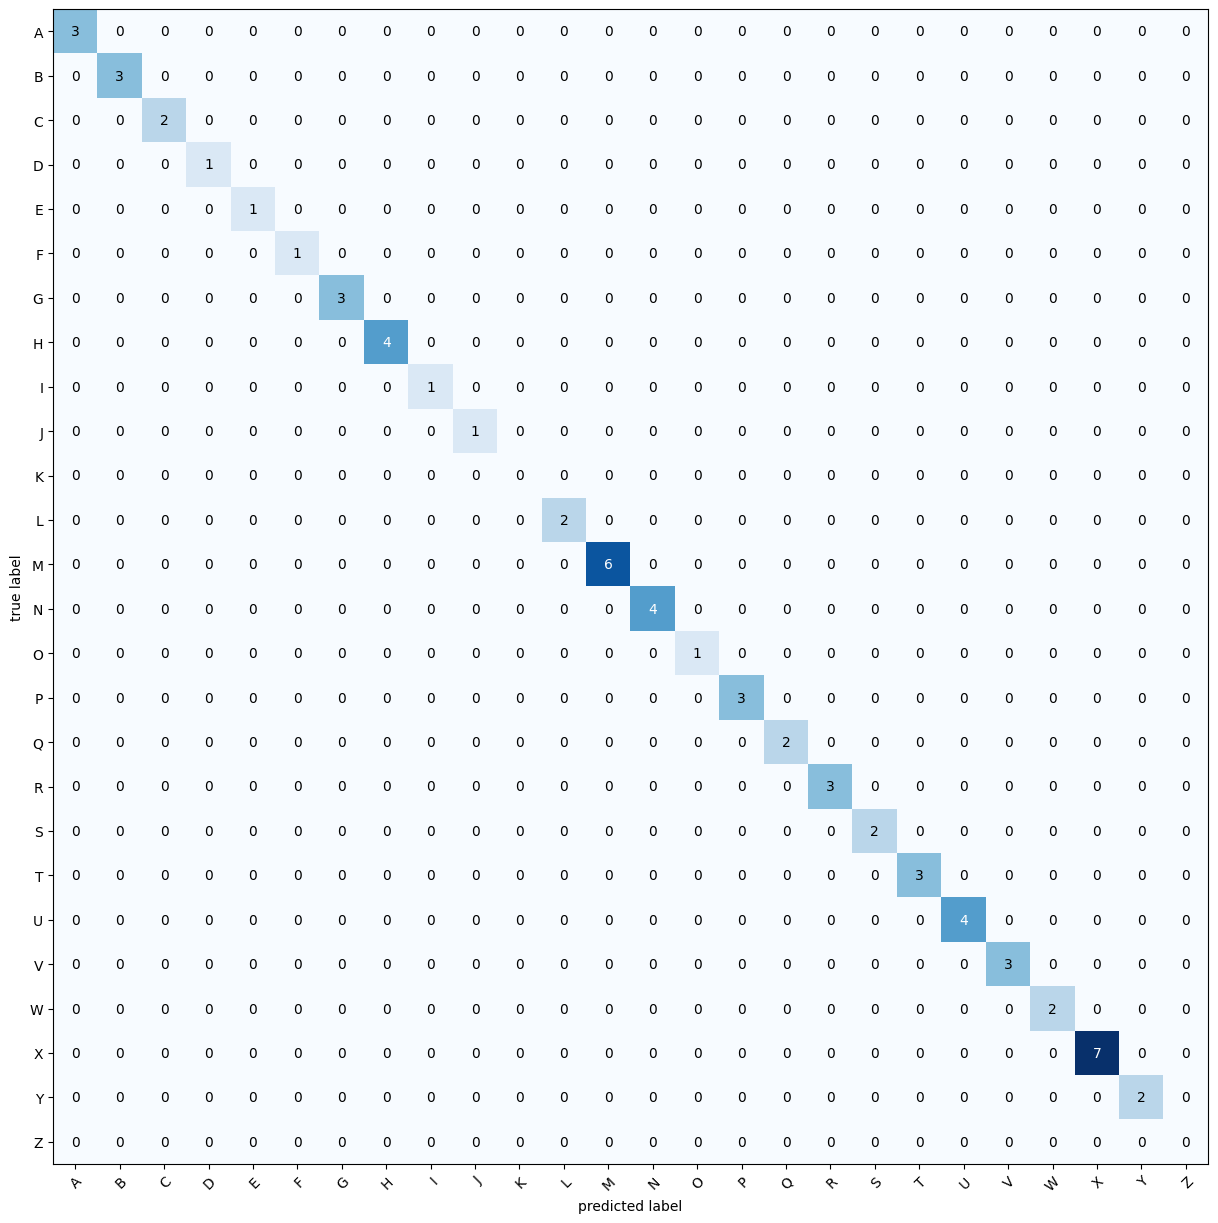

In [22]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt

mat=ConfusionMatrix(num_classes=len(class_names),task="multiclass")
mat_tensor=mat(preds=pred,target=Y)

fig,ax=plot_confusion_matrix(conf_mat=mat_tensor.numpy(),figsize=(15,15),class_names=class_names)
plt.show()

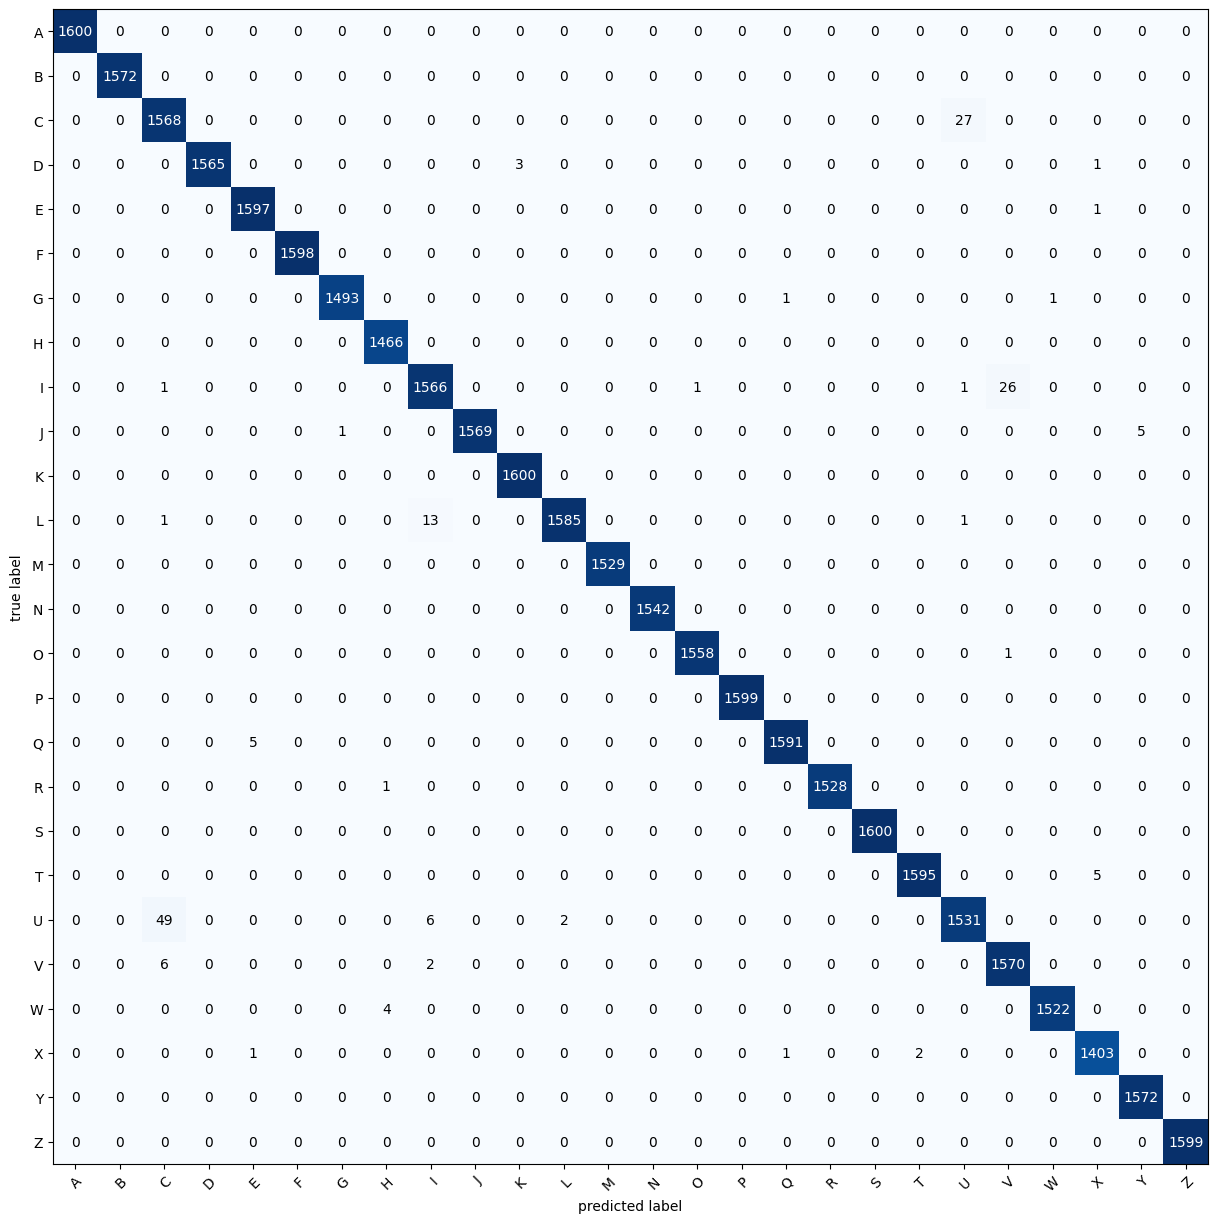

In [23]:
all_preds = []
all_labels = []

model_0.eval()
with torch.inference_mode():
    for X, Y in test_data:
        X, Y = X.to(device), Y.to(device)
        preds = model_0(X).argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(Y.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

mat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
mat_tensor = mat(preds=all_preds, target=all_labels)

fig, ax = plot_confusion_matrix(
    conf_mat=mat_tensor.numpy(),
    class_names=class_names,
    figsize=(15, 15)
)